In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

In [2]:
# Load dataset
df = pd.read_csv("fraud_detection_data.csv")

# Data Preprocessing
# Handling missing values
df.fillna(df.median(), inplace=True)

In [3]:
# Encoding categorical features
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature Scaling
scaler = StandardScaler()
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']

In [4]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_scaled = scaler.fit_transform(X_resampled)

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)


In [5]:
# Model Selection
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=15, min_samples_split=3, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [6]:
# Metrics Calculation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Print metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc * 100:.2f}%")

Accuracy: 95.97%
Precision: 93.53%
Recall: 98.78%
F1-score: 96.08%
ROC-AUC Score: 97.95%


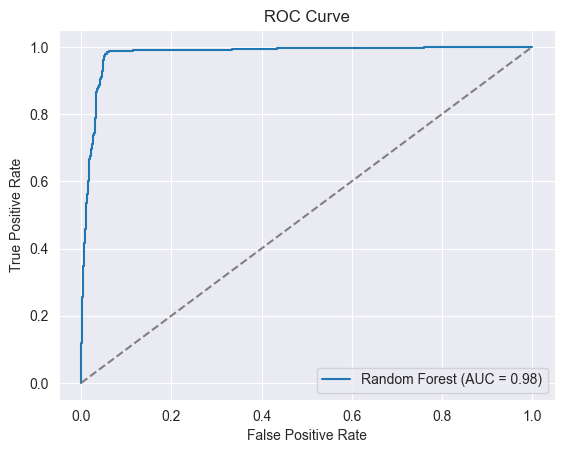

In [7]:
# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


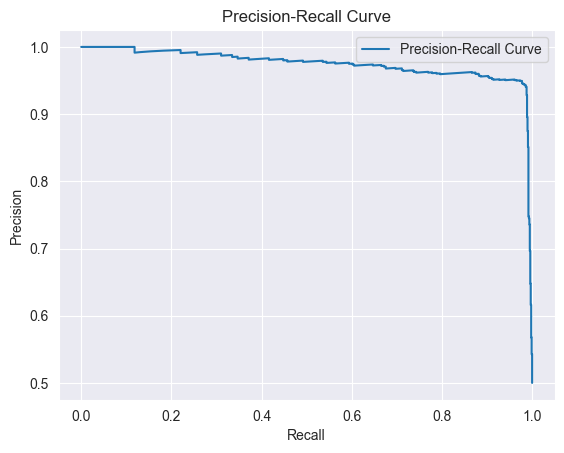

In [8]:
# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs)
plt.figure()
plt.plot(recall_vals, precision_vals, label='Precision-Recall Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
# Fraud Detection Test Function
def test_fraud_detection(sample_transaction):
    sample_df = pd.DataFrame([sample_transaction])
    sample_scaled = scaler.transform(sample_df)
    prediction = rf_model.predict(sample_scaled)[0]
    return "Fraudulent Transaction" if prediction == 1 else "Legitimate Transaction"

# Example test transaction
sample_transaction = dict(zip(X.columns, X.median()))

# Test the fraud detection function
print(test_fraud_detection(sample_transaction))


Fraudulent Transaction
